EXPLORATORY DATA ANALYSIS.

In [1]:
# Importing the necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the df_unclean dataframe
df = pd.read_csv('../unclean_data/df_unclean.csv')

In [3]:
# Checking few rows
df.head()

,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Tenure Bucket,Agent Shift,CSAT Score,responsetime,responsetime_in_mins,Tenure_Bucket_enc
0,Outcall,Product Queries,Life Insurance,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,On Job Training,Morning,5,0 days 00:34:00,34,0
1,Outcall,Product Queries,Product Specific Information,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,>90,Morning,5,0 days 00:02:00,2,4
2,Inbound,Order Related,Installation/demo,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,On Job Training,Evening,5,0 days 00:22:00,22,0
3,Inbound,Returns,Reverse Pickup Enquiry,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,>90,Evening,5,0 days 00:20:00,20,4
4,Inbound,Cancellation,Not Needed,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,0-30,Morning,5,0 days 00:02:00,2,1


I. Visualising the distribution of CSAT scores.

Skewness: -1.6584233881836223
Kurtosis: 1.1364139927023738


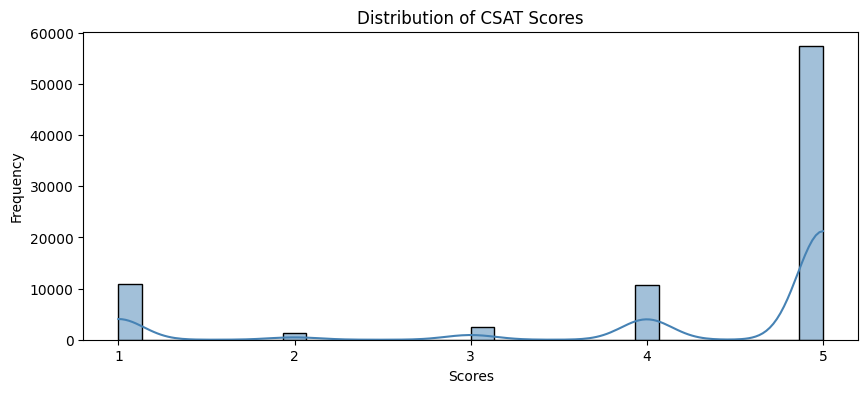

In [14]:
# Calculating the skewness and kurtosis
print(f"Skewness: {df['CSAT Score'].skew()}")
print(f"Kurtosis: {df['CSAT Score'].kurt()}")

# Defining a function to plot the graph
def plot_csat_distibution(df):
    fig, ax = plt.subplots(figsize=(10,4))
    sns.histplot(df['CSAT Score'], bins=30, color='steelblue', kde=True)
    ax.set_title('Distribution of CSAT Scores')
    ax.set_xlabel('Scores')
    ax.set_xticks([1,2,3,4,5])
    ax.set_ylabel('Frequency')
    return fig

plot_csat_distibution(df)
plt.show()

Insights-
- Most customers are satisfied with the services of the platform, as seen from the graph above, since the score of 5 has the highest frequency.
- The data is skewed towards the left (towards the lower scores; negative skewness value).
- The classes are heavily imbalanced.
- The graph is leptokurtic (positive kurtosis value; sharp peak).

II. Visualising the distribution of tenure of the agents.

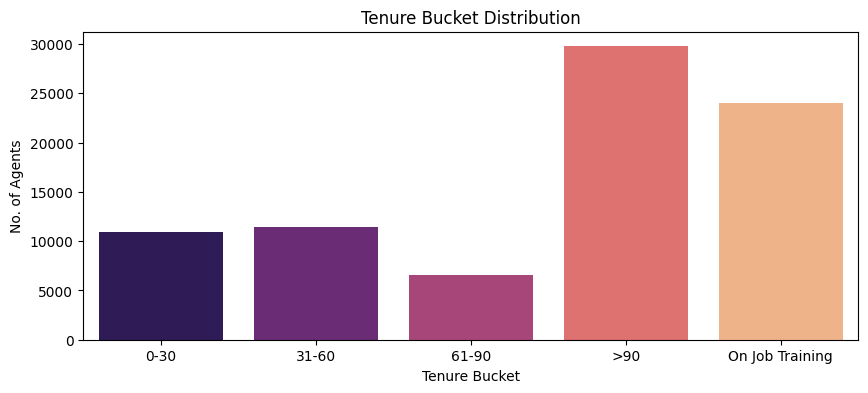

In [5]:
def plot_tenure_distribution (df):
    # Calculating tenure distribution of agents
    tenure_size = df.groupby('Tenure Bucket').size().reset_index(name='count')

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(tenure_size, x='Tenure Bucket', y='count', palette='magma')
    ax.set_title('Tenure Bucket Distribution')
    ax.set_xlabel('Tenure Bucket')
    ax.set_ylabel('No. of Agents')
    return fig

plot_tenure_distribution(df)
plt.show()

Insights-
- Most agents have an experience greater than 90 days.
- Agents who are under training are the second largest group.

III. Visualising how customers interacted with Shopzilla.

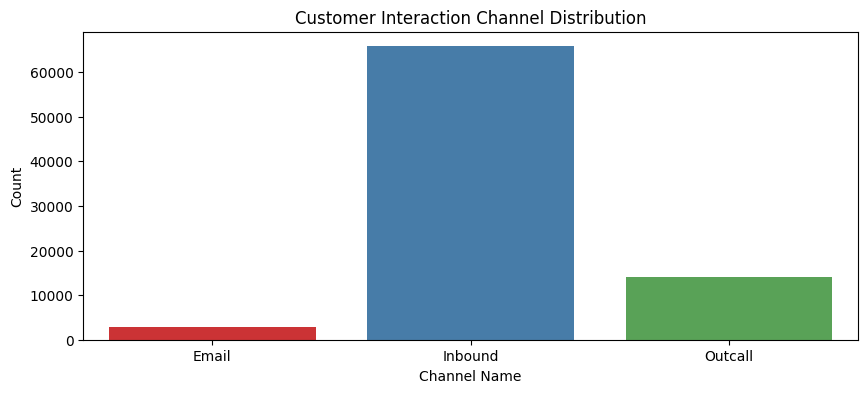

In [6]:
def plot_channel_name (df):
    # Calculating the numbers of interaction via each channel
    channel = df.groupby('channel_name').size().reset_index(name='count')

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(channel, x='channel_name', y='count', palette='Set1')
    ax.set_title('Customer Interaction Channel Distribution')
    ax.set_xlabel('Channel Name')
    ax.set_ylabel('Count')
    return fig

plot_channel_name(df)
plt.show()

Insights-
- Most customers contacted Shopzilla on their own.
- Shopzilla prioritizes call-based support systems.

IV. Visualising the average CSAT scores of each channel.

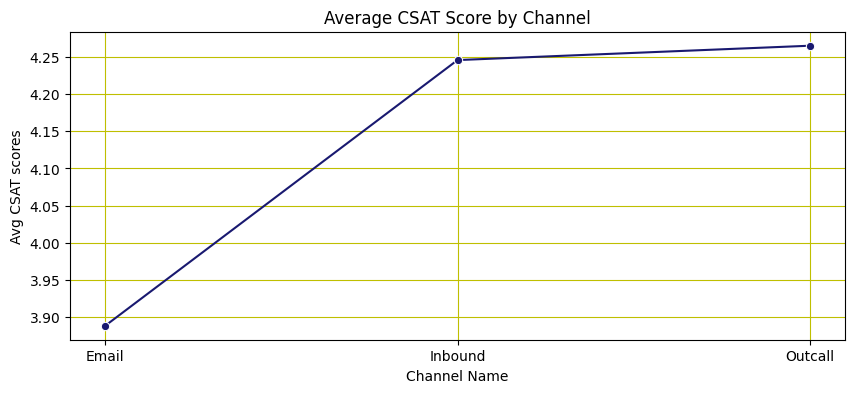

In [7]:
def plot_csat_channel(df):
    # Calculating the average CSAT scores for each channel
    avg_csat_channel = df.groupby('channel_name')['CSAT Score'].mean().reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(avg_csat_channel, x='channel_name', y='CSAT Score', marker='o', color='midnightblue')
    ax.set_title('Average CSAT Score by Channel')
    ax.set_xlabel('Channel Name')
    ax.set_ylabel('Avg CSAT scores')
    ax.grid(color='y')
    return fig

plot_csat_channel(df)
plt.show()

Insights-
- Proactive or follow-up calls tend to increase customer satisfaction.
- Reactive calls or customers contacting support directly, generally receive effective resolution.
- Support via e-mails may involve slower response time, delayed resolution or less effective resoultion due to less interactive communication, that decrease customer satisfaction.

V. Visualising the Customer Interaction count by Category.

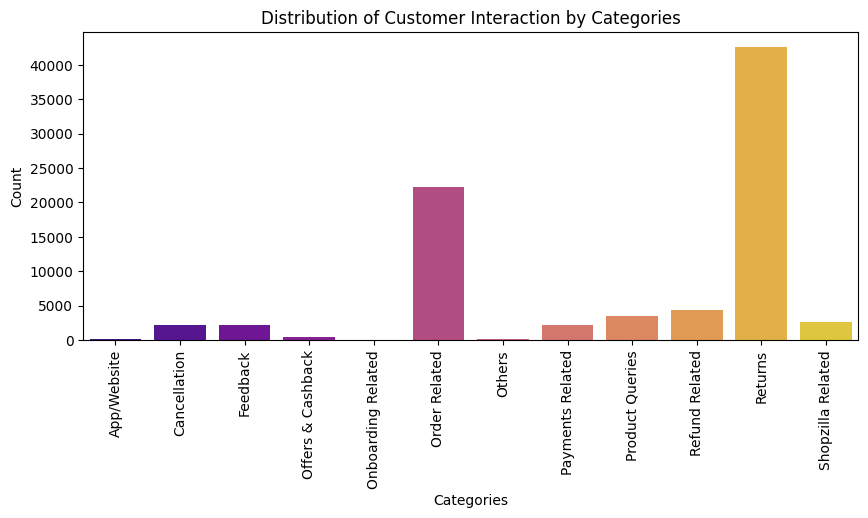

In [8]:
def plot_category_distribution(df):
    # Calculating the interaction count by category
    category = df.groupby('category').size().reset_index(name='count')

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.barplot(category, x='category', y='count', palette='plasma')
    ax.set_title('Distribution of Customer Interaction by Categories')
    ax.set_xlabel('Categories')
    ax.set_ylabel('Count')
    plt.xticks(rotation=90)
    return fig

plot_category_distribution(df)
plt.show()

Insights-
- Customer interactions due to returns is the highest among the categories. This might be due to return processes or product quality and expectations.
- While, Order Related Queries are the second highest among the categories of interactions.
- Improving these areas could significantly reduce customer-support workload and increase customer satisfaction.

VI. Visualising the distribution of time taken to respond to customers

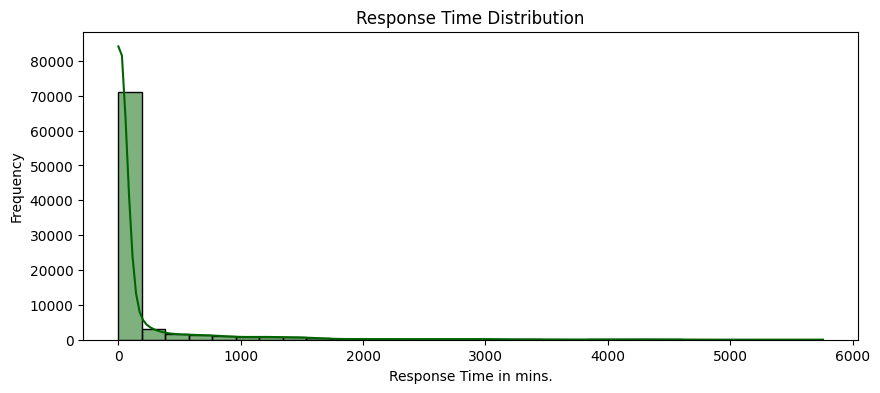

In [9]:
def plot_response_distribution(df):
    fig, ax = plt.subplots(figsize=(10,4))
    sns.histplot(df['responsetime_in_mins'], bins=30, kde=True, color='darkgreen')
    ax.set_title('Response Time Distribution')
    ax.set_xlabel('Response Time in mins.')
    ax.set_ylabel('Frequency')
    return fig

plot_response_distribution(df)
plt.show()

Insights-
- Most queries of customers' are resolved within few minutes.
- The long tail represents higher response time for the queries. Working on reducing the response time could improve customer satisfaction.

VII. Visualising the CSAT Scores across Agent Tenure Buckets.

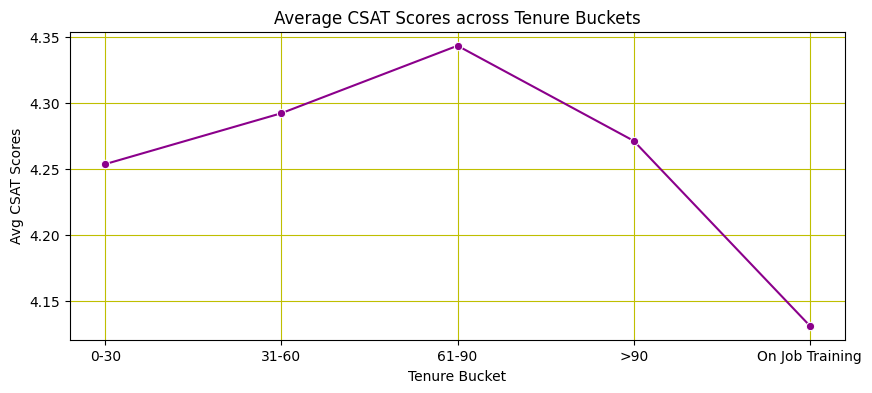

In [10]:
def plot_avg_csat_tenure (df):
    # Calculating the average CSAT score for each tenure bucket
    avg_csat_tenure = df.groupby('Tenure Bucket')['CSAT Score'].mean().reset_index()

    # Plotting the graph
    fig, ax  = plt.subplots(figsize=(10,4))
    sns.lineplot(avg_csat_tenure, x='Tenure Bucket', y='CSAT Score', color='darkmagenta', marker='o')
    ax.set_title('Average CSAT Scores across Tenure Buckets')
    ax.set_xlabel('Tenure Bucket')
    ax.set_ylabel('Avg CSAT Scores')
    ax.grid(color='y')
    return fig

plot_avg_csat_tenure(df)
plt.show()

Insights-
- Initially, CSAT scores increase with experience, that suggests agents become more effective after gaining some work experience.
- Agents under training have the lowest satisfaction score.
- Agents with experience above 90 days show a slight decrease in the CSAT score, possibly due to reduced supervision, handling more complex cases or workload fatigue.

VIII. Visualising CSAT scores vs Response Time.

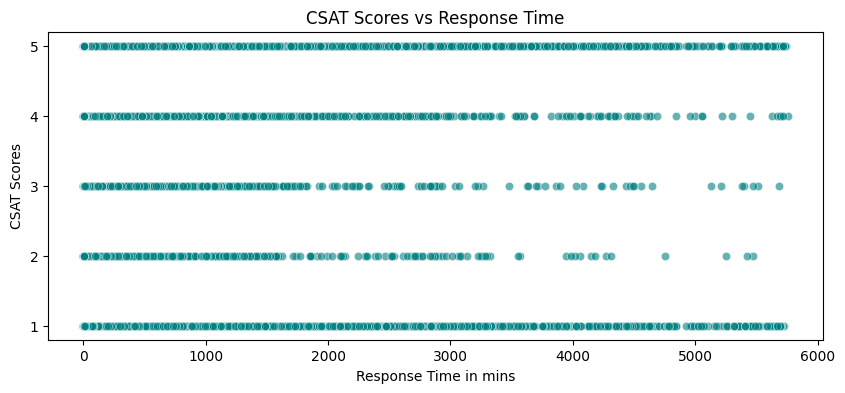

In [11]:
def plot_csat_response (df):
    fig, ax = plt.subplots(figsize=(10,4))
    sns.scatterplot(df, x='responsetime_in_mins', y='CSAT Score', color='teal', alpha=0.6)
    ax.set_title('CSAT Scores vs Response Time')
    ax.set_xlabel('Response Time in mins')
    ax.set_ylabel('CSAT Scores')
    ax.set_yticks([1,2,3,4,5])
    return fig

plot_csat_response(df)
plt.show()

Insights-
- From the graph above we can see that slower response time does not necessarily mean that customers are not satisfied. Both the scores of 1 and 5 have high response time.
- This suggests that other factors (agent behaviour, quality of resolution, etc) are affecting the satisfaction scores of customers.

IX. Visualising the Average Response Time by Channel.

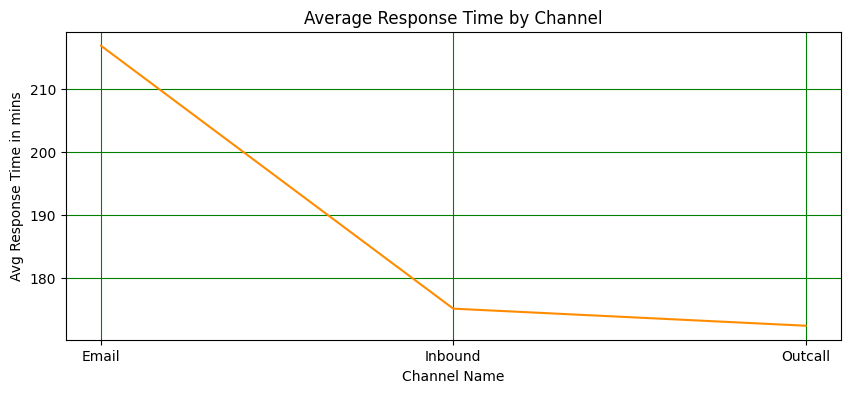

In [12]:
def plot_avg_responsetime_channel(df):
    # Calculating the average response time per channel
    avg_responsetime_channel = df.groupby('channel_name')['responsetime_in_mins'].mean().reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(avg_responsetime_channel, x='channel_name', y='responsetime_in_mins', color='darkorange')
    ax.grid(color='g')
    ax.set_title('Average Response Time by Channel')
    ax.set_xlabel('Channel Name')
    ax.set_ylabel('Avg Response Time in mins')
    return fig

plot_avg_responsetime_channel(df)
plt.show()

Insights-
- Response time is quicker in cases of proactive calls, that is when the agent reaches out to the customers.
- E-mails take the longest response time.
- Inbound or reactive calls are also addressed and resolved quickly.
- Training the agents involved with Emails so as to reduce response time, could improve customer satisfaction.

X. Visualising CSAT Scores by Category.

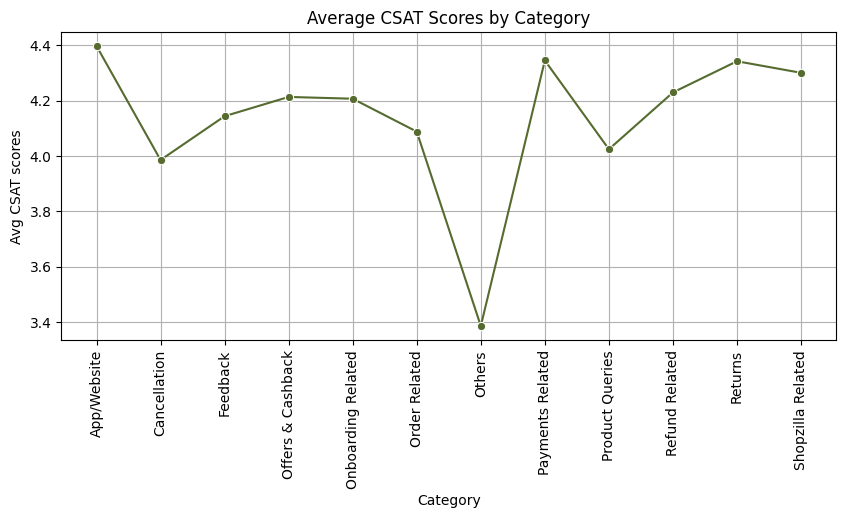

In [13]:
def plot_csat_category (df):
    # Calculating the average csat scores for each category
    csat_category = df.groupby('category')['CSAT Score'].mean().reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(csat_category, x='category', y='CSAT Score', color='darkolivegreen', marker='o')
    ax.grid()
    ax.set_title('Average CSAT Scores by Category')
    ax.set_xlabel('Category')
    ax.set_ylabel('Avg CSAT scores')
    plt.xticks(rotation=90)
    return fig

plot_csat_category(df)
plt.show()

Insights-
- Majority of the categories perform well and customers are satisfied with the resolution they receive from agents.
- Customers were not satisfied with resolutions provided by agents for 'Others' category, hence the lowest average satisfaction score.

XI. Visualising the Response Time by Category.

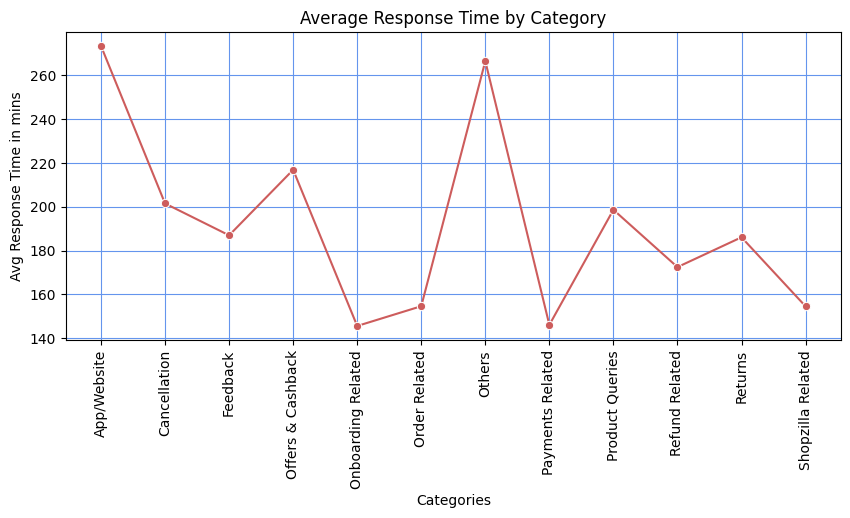

In [19]:
def plot_avg_responsetime_category(df):
    # Calculatinig the average response time for each category
    avg_responsetime_category = df.groupby('category')['responsetime_in_mins'].mean().reset_index()

    # Plotting the graph
    fig, ax = plt.subplots(figsize=(10,4))
    sns.lineplot(avg_responsetime_category, x='category', y='responsetime_in_mins', color='indianred', marker='o')
    ax.set_title('Average Response Time by Category')
    ax.set_xlabel('Categories')
    ax.grid(color='cornflowerblue')
    plt.xticks(rotation=90)
    ax.set_ylabel('Avg Response Time in mins')
    return fig

plot_avg_responsetime_category(df)
plt.show()

Insights-
- Queries are resolved within 5 hours on an average.
- App/Website related issues take the longest to solve; the technical team should make necessary changes to improve the platform's app/website which could improve customer satisfaction.
- "Others" category takes the second longest time to resolve. This might be possibly due to additional investigation to understand the problem before responding.

XII. Visualising Interaction Volume by Agent Shift.

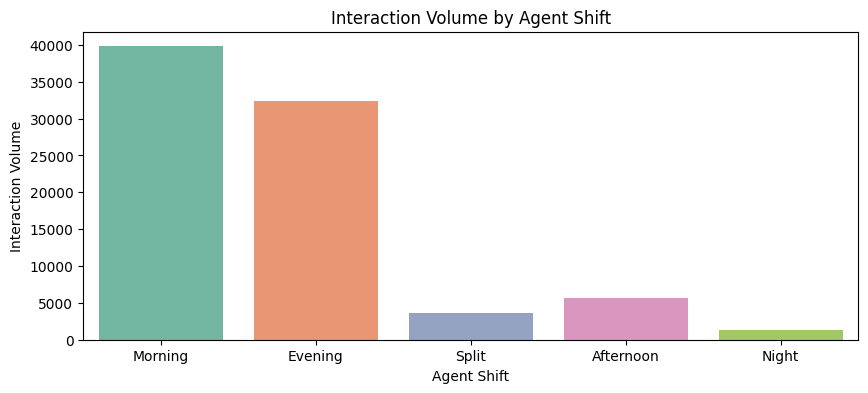

In [22]:
def plot_agent_interaction_vol (df):
    fig, ax = plt.subplots(figsize=(10,4))
    sns.countplot(df, x='Agent Shift', palette='Set2')
    ax.set_title('Interaction Volume by Agent Shift')
    ax.set_ylabel('Interaction Volume')
    return fig

plot_agent_interaction_vol(df)
plt.show()

Insights-
- Customer Support staffs should prioritize morning and evening calls, as these periods experience the highest customer interaction volume.
- Optimising agent allocation during the peak hours could improve response efficiency and customer satisfaction.